In [3]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = (iris.target == 2)

svm_clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=1, random_state=42))
svm_clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [5]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

In [6]:
svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761])

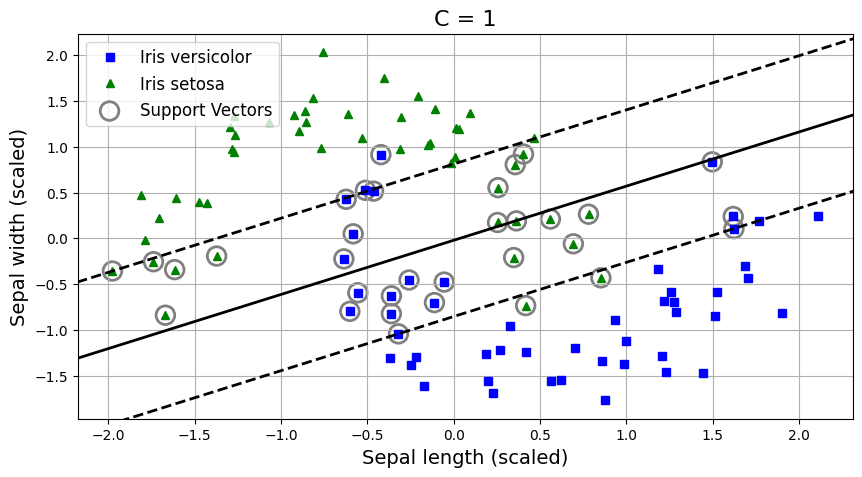

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

def plot_svc_decision_boundary(svm_clf, x_min, x_max):
    """
    画出线性SVM的决策边界、间隔边界和支持向量
    """
    # 获取模型的权重 w 和 偏置 b
    # 决策边界公式为：w0*x0 + w1*x1 + b = 0
    # 整理为斜截式 (x1 = ...): x1 = -w0/w1 * x0 - b/w1
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # 生成 x0 (横坐标) 的点
    x0 = np.linspace(x_min, x_max, 200)
    
    # 1. 计算决策边界 (Decision boundary, 即 z=0)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    # 2. 计算间隔边界 (Margins)
    # SVM的间隔边界对应 z = 1 和 z = -1
    # 上边界 (z=1) 对应: w0*x0 + w1*x1 + b = 1
    # 下边界 (z=-1) 对应: w0*x0 + w1*x1 + b = -1
    # slope = -w[0]/w[1]
    margin = 1/w[1] # 这是基于标准化的单位长度
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    # 3. 提取支持向量 (Support Vectors)
    # 模型的 support_vectors_ 属性保存了这些点的坐标
    svs = svm_clf.support_vectors_

    # --- 开始绘图 ---
    # 画决策边界（实黑线）
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    # 画上下间隔边界（虚黑线）
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)
    
    # 用灰色圆圈圈出支持向量
    # s=180 是圆圈的大小，facecolors='none' 表示空心圆，edgecolors='gray' 圆圈颜色
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='none', 
                edgecolors='gray', linewidths=2, label='Support Vectors')

# 设置网格背景
plt.figure(figsize=(10, 5))
plt.grid(True)

# 画出数据点
# 类别0 用蓝色正方形 ('bs')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.plot(X_scaled[y==1, 0], X_scaled[y==1, 1], "bs", label="Iris versicolor")
# 类别1 用绿色三角形 ('g^')
plt.plot(X_scaled[y==0, 0], X_scaled[y==0, 1], "g^", label="Iris setosa")

# 调用函数画边界和支持向量
# 获取当前x轴的范围作为输入
current_axes = plt.gca()
x_lim = current_axes.get_xlim()
C_value = 1
svm_clf = SVC(kernel='linear', C=C_value)
svm_clf.fit(X_scaled, y)
plot_svc_decision_boundary(svm_clf, x_lim[0], x_lim[1])

# 设置标签和标题
plt.xlabel("Sepal length (scaled)", fontsize=14)
plt.ylabel("Sepal width (scaled)", fontsize=14)
plt.title(f"C = {C_value}", fontsize=16)
plt.legend(loc="upper left", fontsize=12)

# 调整坐标轴刻度，让支持向量的圆圈能完整显示
plt.axis([X_scaled[:, 0].min()-0.2, X_scaled[:, 0].max()+0.2, 
          X_scaled[:, 1].min()-0.2, X_scaled[:, 1].max()+0.2])

plt.show()

In [14]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=1, max_iter=10000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


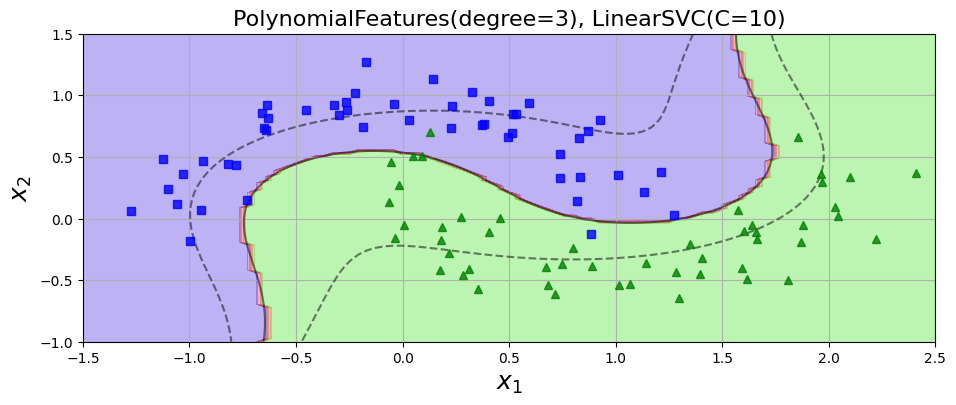

In [15]:
def plot_dataset(X, y, axes):
    """
    画出数据点
    """
    # 类别0 用蓝色正方形 ('bs')
    plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", alpha=0.8)
    # 类别1 用绿色三角形 ('g^')
    plt.plot(X[y == 1, 0], X[y == 1, 1], "g^", alpha=0.8)
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18)

def plot_predictions(clf, axes):
    """
    画出预测区域和决策边界线
    """
    # a. 生成网格数据点，覆盖绘图区域
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    # 将网格展平为两列的特征矩阵
    X_grid = np.c_[x0.ravel(), x1.ravel()]
    
    # b. 用模型预测网格中每个点的类别 (0 或 1)
    y_pred = clf.predict(X_grid).reshape(x0.shape)
    
    # c. 用模型预测网格中每个点的“决策分数”（用于画边界线）
    # 在 LinearSVC 中是 z = w*x + b。z=0 即为边界
    # z > 0 (通常对应类1) z < 0 (通常对应类0)
    # 注意：多项式特征是在 clf 内部处理的
    y_decision = clf.decision_function(X_grid).reshape(x0.shape)

    # d. 绘图：填充区域颜色 (Contourf)
    # 复现原图中的紫色(类0)和浅绿色(类1)背景
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.3)
    
    # e. 绘图：画决策边界分数线 (Contour)
    # 我们画三条线：
    # z=0 (实线): 决策边界
    # z=1, z=-1 (虚线): 类似于SVC的间隔边界
    # colors='k' 为黑线
    plt.contour(x0, x1, y_decision, colors='k',
                 levels=[-1, 0, 1], alpha=0.5,
                 linestyles=['--', '-', '--'])
    
plt.figure(figsize=(11, 4))

# 复现原图的坐标轴范围
plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1.0, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1.0, 1.5])

plt.title(f"PolynomialFeatures(degree=3), LinearSVC(C=10)", fontsize=16)
plt.show()